# Пример чтения файлов формата `.bag`
В данном блокноте приведен пример чтения технических данных из Робота Unitree A1 ИТ-Центра МАИ по имени Дора.
Данный формат широко распространен для записи технических параметров в системах ROS

Установка необходимых пакетов

In [1]:
%pip install bagpy

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 12.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 633.2/633.2 kB 13.8 MB/s  0:00:00
  Created wheel for gnupg: filename=gnupg-2.3.1-py3-none-any.whl size=94718 sha256=b40cecd154e2d965b5390b9ff7d423e3bb66ecaf3b6bfe080cea28cf42e3a116
  Stored in directory: /Users/elzaalpnva/Library/Caches/pip/wheels/96/4a/73/180cbdac353bcb2d052618ece30442fd2d0b07df995b7e39eb
Successfully built gnupg
  Attempting uninstall: jinja2━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  4/19 [pycryptodomex]
    Found existing installation: Jinja2 3.1.6━━━━━━━━━━━━━━━━━  4/19 [pycryptodomex]
    Uninstalling Jinja2-3.1.6:m━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  4/19 [pycryptodomex]
      Successfully uninstalled Jinja2-3.1.6━━━━━━━━━━━━━━━━━━━  4/19 [pycryptodomex]


Подключаем необходимые библиотеки:

In [2]:
import bagpy
from bagpy import bagreader
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [5]:
b = bagreader('20230117_183740.bag')

[INFO]  Successfully created the data folder 20230117_183740.


Посмотрим какие данные сохранены в файле

In [6]:
#Если хотим посмотреть все топики в файле
#pd.set_option('display.max_rows', None)
b.topic_table

,Topics,Types,Message Count,Frequency
0,/device_0/info,diagnostic_msgs/KeyValue,13,NaN
1,/device_0/sensor_0/Depth_0/image/data,sensor_msgs/Image,394,14.988542
2,/device_0/sensor_0/Depth_0/image/metadata,diagnostic_msgs/KeyValue,9456,NaN
3,/device_0/sensor_0/Depth_0/info,realsense_msgs/StreamInfo,1,NaN
4,/device_0/sensor_0/Depth_0/info/camera_info,sensor_msgs/CameraInfo,1,NaN
...,...,...,...,...
102,/device_0/sensor_2/option/Frames_Queue_Size/de...,std_msgs/String,1,NaN
103,/device_0/sensor_2/option/Frames_Queue_Size/value,std_msgs/Float32,1,NaN
104,/device_0/sensor_2/option/Global_Time_Enabled/...,std_msgs/String,1,NaN
105,/device_0/sensor_2/option/Global_Time_Enabled/...,std_msgs/Float32,1,NaN


## Декодирование сообщений из топика

In [7]:
msgsImu_MSG = b.message_by_topic('/device_0/sensor_2/Accel_0/imu/data')
msgsImu_MSG

'20230117_183740/device_0-sensor_2-Accel_0-imu-data.csv'

In [8]:
df_msgsImu = pd.read_csv(msgsImu_MSG)
df_msgsImu

,Time,header.seq,header.stamp.secs,header.stamp.nsecs,header.frame_id,orientation.x,orientation.y,orientation.z,orientation.w,orientation_covariance_0,...,linear_acceleration.z,linear_acceleration_covariance_0,linear_acceleration_covariance_1,linear_acceleration_covariance_2,linear_acceleration_covariance_3,linear_acceleration_covariance_4,linear_acceleration_covariance_5,linear_acceleration_covariance_6,linear_acceleration_covariance_7,linear_acceleration_covariance_8
0,0.000383,47404,1673969860,238107681,1,0.0,0.0,0.0,0.0,0.0,...,-0.107873,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.010330,47405,1673969860,247928381,1,0.0,0.0,0.0,0.0,0.0,...,-0.107873,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.020583,47406,1673969860,257749557,1,0.0,0.0,0.0,0.0,0.0,...,-0.098066,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.030097,47407,1673969860,267572165,1,0.0,0.0,0.0,0.0,0.0,...,-0.107873,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.041590,47408,1673969860,277393103,1,0.0,0.0,0.0,0.0,0.0,...,-0.117680,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2586,26.254508,50074,1673969886,483981609,1,0.0,0.0,0.0,0.0,0.0,...,-0.117680,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2587,26.264428,50075,1673969886,493787050,1,0.0,0.0,0.0,0.0,0.0,...,-0.117680,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2588,26.274125,50076,1673969886,503591537,1,0.0,0.0,0.0,0.0,0.0,...,-0.117680,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2589,26.283836,50077,1673969886,513395786,1,0.0,0.0,0.0,0.0,0.0,...,-0.098066,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Построим график для линейного ускорения датчика по оси Y.
Обратите внимание, что датчик в процессе эксперимента не перемещался, на него воздействовали лишь вибрации от вентилляторов, расположенных в корпусе робота.

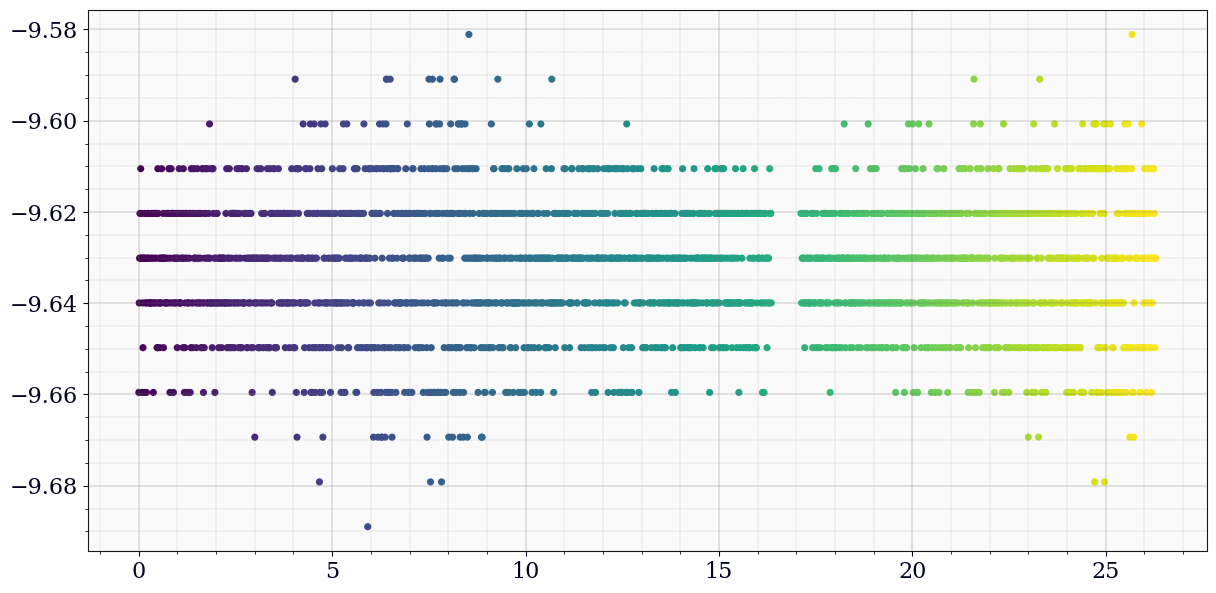

In [9]:
fig, ax = bagpy.create_fig(1)
ax[0].scatter(x='Time', y='linear_acceleration.y', data=df_msgsImu, s= 17, c = 'Time')
plt.show()

## Заглянем в цветную камеру и камеру глубины
На борту робота установлена цветная камера и камера глубины, которые осуществляли съемку в процессе записи bag файла. Доступ к данным можно получить аналогичным способом

In [10]:
sensor_msgsImage_MSG_depth = b.message_by_topic('/device_0/sensor_0/Depth_0/image/data')
sensor_msgsImage_MSG_rgb = b.message_by_topic('/device_0/sensor_1/Color_0/image/data')
sensor_msgsImage_MSG_rgb

'20230117_183740/device_0-sensor_1-Color_0-image-data.csv'

In [11]:
df_sensor_msgsImage = pd.read_csv(sensor_msgsImage_MSG_rgb)
df_sensor_msgsImage

,Time,header.seq,header.stamp.secs,header.stamp.nsecs,header.frame_id,height,width,encoding,is_bigendian,step,data
0,0.039579,6994,1673969860,210257769,1,480,640,rgb8,0,1920,b'\x8d\x8c\x93\x8d\x8c\x93\x8e\x8d\x94\x8d\x8c...
1,0.106640,6995,1673969860,276888609,1,480,640,rgb8,0,1920,b'\x8c\x8b\x90\x8c\x8b\x90\x8d\x8b\x95\x8c\x8a...
2,0.174092,6996,1673969860,343518496,1,480,640,rgb8,0,1920,b'\x8c\x8e\x96\x8c\x8e\x96\x8a\x8e\x95\x8a\x8e...
3,0.239945,6997,1673969860,410146952,1,480,640,rgb8,0,1920,b'\x8e\x8c\x96\x8d\x8b\x95\x8d\x8b\x95\x8c\x8a...
4,0.307951,6998,1673969860,476774216,1,480,640,rgb8,0,1920,b'\x8d\x8c\x93\x8d\x8c\x93\x8e\x8a\x93\x90\x8b...
...,...,...,...,...,...,...,...,...,...,...,...
389,25.994066,7383,1673969886,155333042,1,480,640,rgb8,0,1920,b'\x88\x89\x91\x87\x88\x90\x87\x85\x8f\x88\x87...
390,26.058981,7384,1673969886,221859217,1,480,640,rgb8,0,1920,b'\x86\x8b\x8f\x85\x8a\x8e\x89\x88\x8f\x89\x88...
391,26.128662,7385,1673969886,288382292,1,480,640,rgb8,0,1920,b'\x86\x8c\x8d\x86\x8c\x8d\x84\x89\x8b\x86\x8c...
392,26.192559,7386,1673969886,354902267,1,480,640,rgb8,0,1920,b'\x87\x86\x8d\x87\x86\x8d\x88\x87\x8e\x88\x87...


In [12]:
df_sensor_msgsImage_depth = pd.read_csv(sensor_msgsImage_MSG_depth)
df_sensor_msgsImage_depth

,Time,header.seq,header.stamp.secs,header.stamp.nsecs,header.frame_id,height,width,encoding,is_bigendian,step,data
0,0.033964,6991,1673969860,210136890,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
1,0.101118,6992,1673969860,276767731,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
2,0.167259,6993,1673969860,343397617,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
3,0.234002,6994,1673969860,410026073,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
4,0.300807,6995,1673969860,476653337,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
...,...,...,...,...,...,...,...,...,...,...,...
389,25.986207,7380,1673969886,155212402,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
390,26.053176,7381,1673969886,221738577,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
391,26.119521,7382,1673969886,288261414,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
392,26.186304,7383,1673969886,354781628,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...


Далее можно считать изображение из Pandas DataFrame, однако в таком формате его использовать неудобно, поэтому добавим немного магии для преобразования в удобный вид цветного изображения

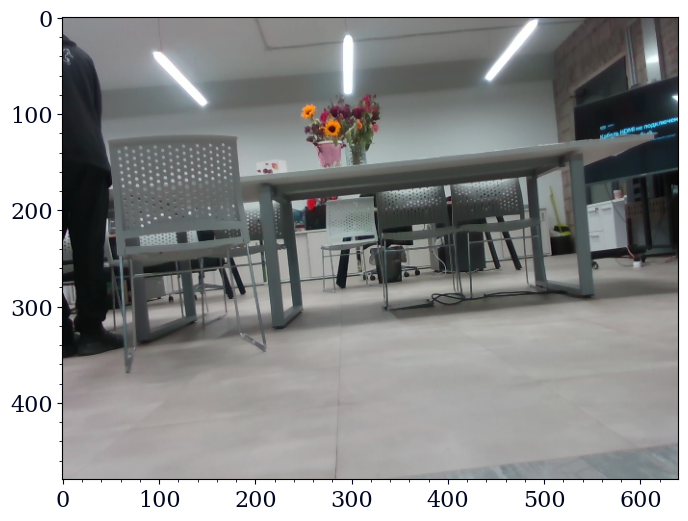

In [13]:
# size of image
H = 480
W = 640

# receive the image we are interested in from the Pandas DataFrame
raw_string = df_sensor_msgsImage['data'][0]

# convert to byte string with escape characters included
byte_string = raw_string[2:-1].encode('latin1')

# remove escaped characters
escaped_string = byte_string.decode('unicode_escape')

# convert back to byte string without escaped characters
byte_string = escaped_string.encode('latin1')

# convert string to numpy array
nparr = np.frombuffer(byte_string, np.uint8)

# convert to 3 channel rgb image array of (H x W x 3)
rgb = nparr.reshape((H, W, -1))

# show image in matplotlib
plt.imshow(rgb)

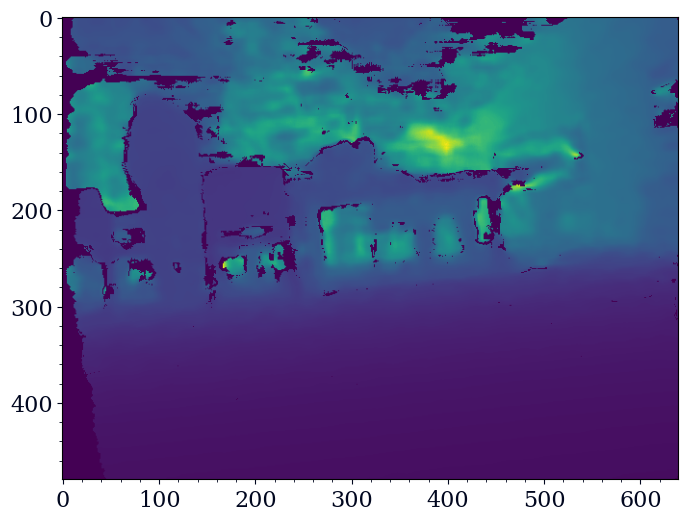

In [14]:
# size of image
H = 480
W = 640

# receive the image we are interested in from the Pandas DataFrame
raw_string = df_sensor_msgsImage_depth['data'][0]

# convert to byte string with escape characters included
byte_string = raw_string[2:-1].encode('latin1')

# remove escaped characters
escaped_string = byte_string.decode('unicode_escape')

# convert back to byte string without escaped characters
byte_string = escaped_string.encode('latin1')

# convert string to numpy array
nparr = np.frombuffer(byte_string, np.uint8)

# convert to 3 channel rgb image array of (H x W x 3)
rgb = nparr.view(np.uint16).reshape((H, W, -1))

# show image in matplotlib
plt.imshow(rgb)

## Практическое задание
* Попробуйте считать какие-либо параметры датчиков из данного файла, например, акселерометра
* Постройте параметры в виде графиков в matplotlib

In [28]:
pd.set_option('display.max_rows', None)

b.topic_table

,Topics,Types,Message Count,Frequency
0,/device_0/info,diagnostic_msgs/KeyValue,13,NaN
1,/device_0/sensor_0/Depth_0/image/data,sensor_msgs/Image,394,14.988542
2,/device_0/sensor_0/Depth_0/image/metadata,diagnostic_msgs/KeyValue,9456,NaN
3,/device_0/sensor_0/Depth_0/info,realsense_msgs/StreamInfo,1,NaN
4,/device_0/sensor_0/Depth_0/info/camera_info,sensor_msgs/CameraInfo,1,NaN
5,/device_0/sensor_0/Depth_0/tf/0,geometry_msgs/Transform,1,NaN
6,/device_0/sensor_0/info,diagnostic_msgs/KeyValue,2,NaN
7,/device_0/sensor_0/option/Asic_Temperature/des...,std_msgs/String,1,NaN
8,/device_0/sensor_0/option/Asic_Temperature/value,std_msgs/Float32,1,NaN
9,/device_0/sensor_0/option/Depth_Units/description,std_msgs/String,1,NaN


In [29]:
imu_topic = b.message_by_topic('/device_0/sensor_2/Accel_0/imu/data')

df_imu = pd.read_csv(imu_topic)

df_imu.head()

,Time,header.seq,header.stamp.secs,header.stamp.nsecs,header.frame_id,orientation.x,orientation.y,orientation.z,orientation.w,orientation_covariance_0,...,linear_acceleration.z,linear_acceleration_covariance_0,linear_acceleration_covariance_1,linear_acceleration_covariance_2,linear_acceleration_covariance_3,linear_acceleration_covariance_4,linear_acceleration_covariance_5,linear_acceleration_covariance_6,linear_acceleration_covariance_7,linear_acceleration_covariance_8
0,0.000383,47404,1673969860,238107681,1,0.0,0.0,0.0,0.0,0.0,...,-0.107873,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.010330,47405,1673969860,247928381,1,0.0,0.0,0.0,0.0,0.0,...,-0.107873,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.020583,47406,1673969860,257749557,1,0.0,0.0,0.0,0.0,0.0,...,-0.098066,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.030097,47407,1673969860,267572165,1,0.0,0.0,0.0,0.0,0.0,...,-0.107873,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.041590,47408,1673969860,277393103,1,0.0,0.0,0.0,0.0,0.0,...,-0.117680,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
df_imu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2591 entries, 0 to 2590
Data columns (total 42 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Time                              2591 non-null   float64
 1   header.seq                        2591 non-null   int64  
 2   header.stamp.secs                 2591 non-null   int64  
 3   header.stamp.nsecs                2591 non-null   int64  
 4   header.frame_id                   2591 non-null   int64  
 5   orientation.x                     2591 non-null   float64
 6   orientation.y                     2591 non-null   float64
 7   orientation.z                     2591 non-null   float64
 8   orientation.w                     2591 non-null   float64
 9   orientation_covariance_0          2591 non-null   float64
 10  orientation_covariance_1          2591 non-null   float64
 11  orientation_covariance_2          2591 non-null   float64
 12  orient

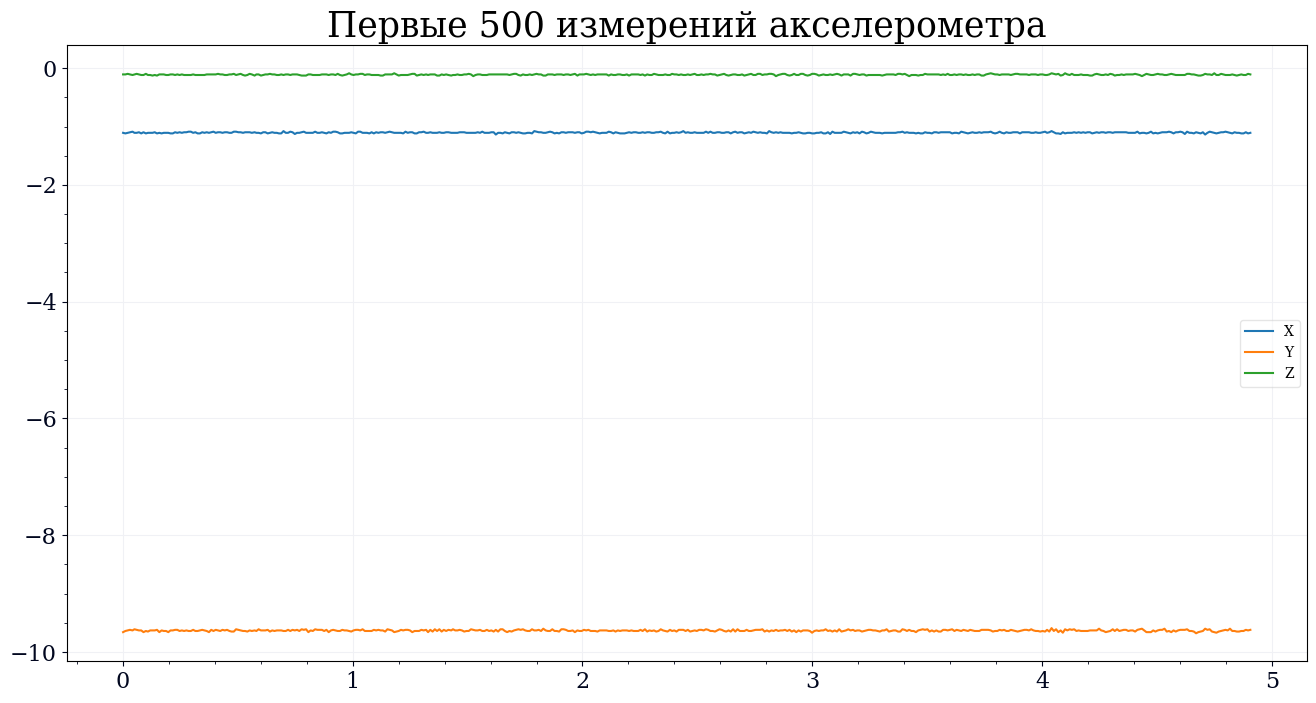

In [31]:
subset = df_imu.iloc[:500]

plt.figure(figsize=(16,8))

plt.plot(subset['Time'],
         subset['linear_acceleration.x'],
         label='X')

plt.plot(subset['Time'],
         subset['linear_acceleration.y'],
         label='Y')

plt.plot(subset['Time'],
         subset['linear_acceleration.z'],
         label='Z')

plt.title('Первые 500 измерений акселерометра')

plt.legend()
plt.grid()

plt.show()

In [32]:
print(df_imu[['linear_acceleration.x',
              'linear_acceleration.y',
              'linear_acceleration.z']].describe())

       linear_acceleration.x  linear_acceleration.y  linear_acceleration.z
count            2591.000000            2591.000000            2591.000000
mean               -1.103810              -9.632465              -0.111200
std                 0.009248               0.014512               0.008819
min                -1.137571              -9.688970              -0.137293
25%                -1.108151              -9.639936              -0.117680
50%                -1.108151              -9.630130              -0.107873
75%                -1.098345              -9.620323              -0.107873
max                -1.068925              -9.581097              -0.078453


In [33]:
print(df_imu['linear_acceleration.x'].unique()[:20])

[-1.10815144 -1.11795807 -1.0983448  -1.08853817 -1.07873142 -1.1277647
 -1.13757133 -1.06892478]


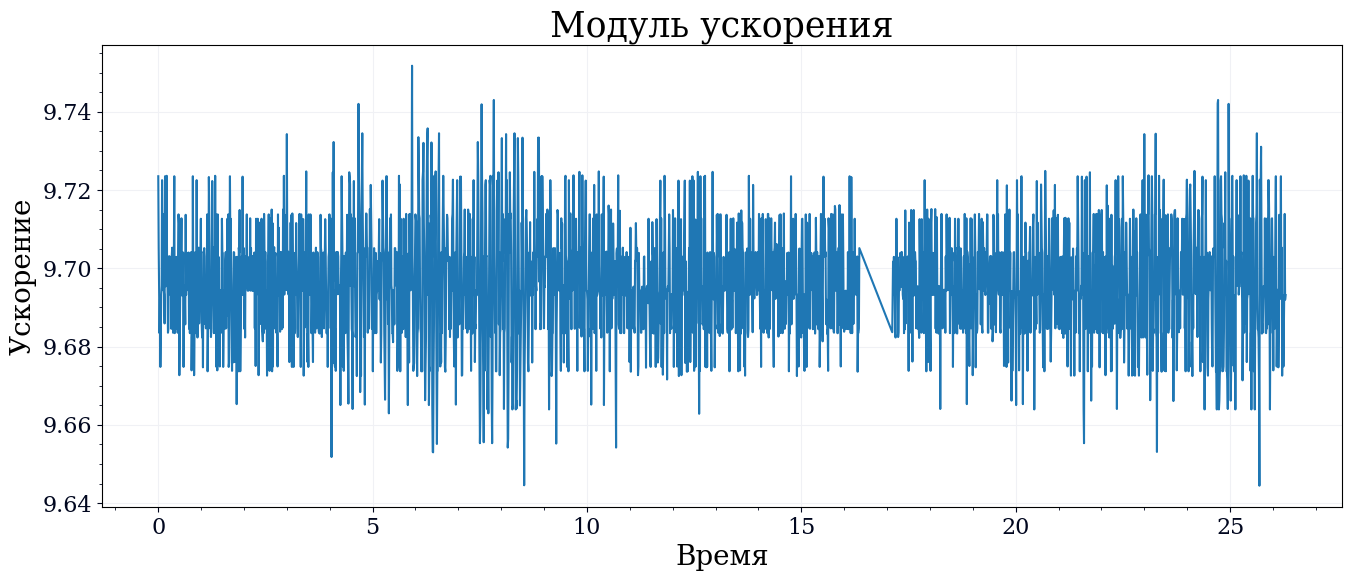

In [36]:
acc_magnitude = np.sqrt(
    df_imu['linear_acceleration.x']**2 +
    df_imu['linear_acceleration.y']**2 +
    df_imu['linear_acceleration.z']**2
)

plt.figure(figsize=(16,6))

plt.plot(df_imu['Time'], acc_magnitude)

plt.title('Модуль ускорения')
plt.xlabel('Время')
plt.ylabel('Ускорение')

plt.grid()

plt.show()

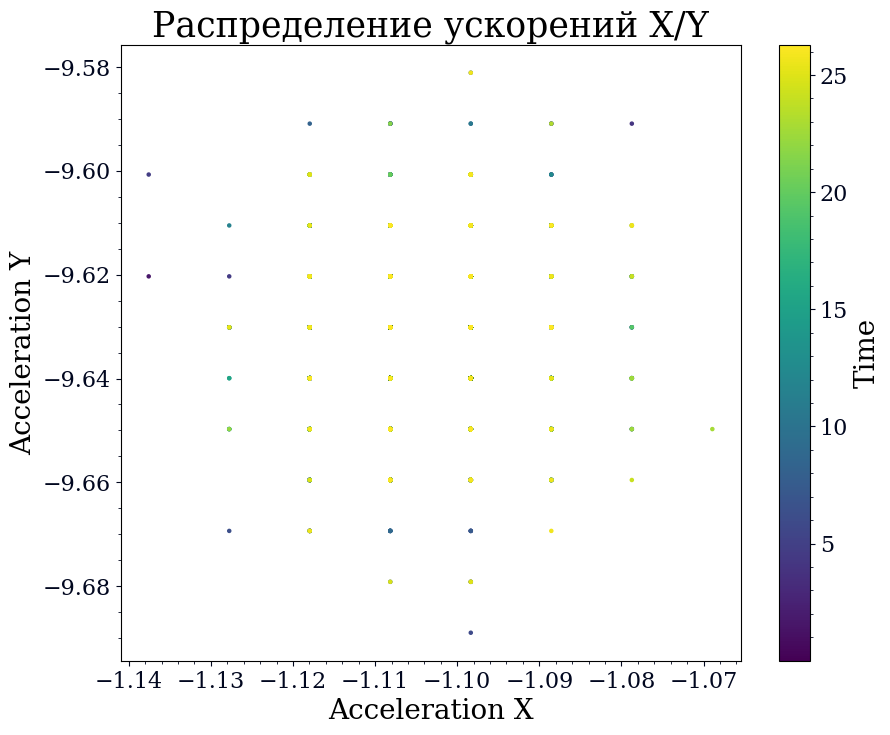

In [37]:
plt.figure(figsize=(10,8))

plt.scatter(
    df_imu['linear_acceleration.x'],
    df_imu['linear_acceleration.y'],
    c=df_imu['Time'],
    s=5
)

plt.title('Распределение ускорений X/Y')
plt.xlabel('Acceleration X')
plt.ylabel('Acceleration Y')

plt.colorbar(label='Time')

plt.show()

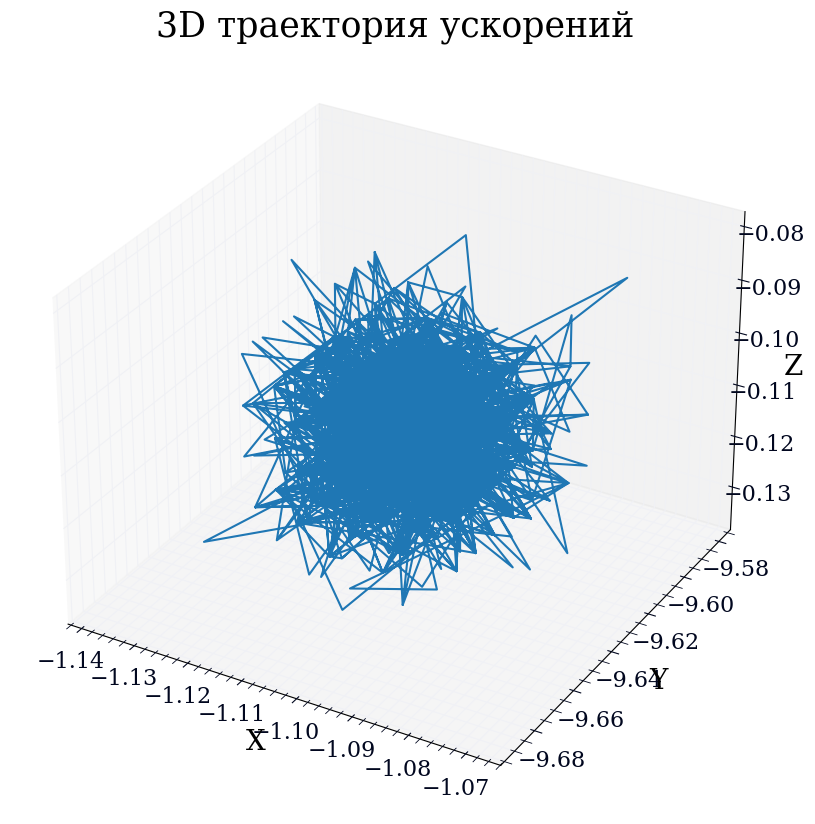

In [38]:
fig = plt.figure(figsize=(10,10))

ax = fig.add_subplot(projection='3d')

ax.plot(
    df_imu['linear_acceleration.x'],
    df_imu['linear_acceleration.y'],
    df_imu['linear_acceleration.z']
)

ax.set_title("3D траектория ускорений")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()